In [1]:
import pandas as pd
import numpy as np

In [3]:
import market_data_setup as stp
import Implied_Vol_extraction as iv

In [5]:
df = pd.read_excel('NiftyOptions.xlsx')
r = 0.045
S0 = 23483.55

In [7]:
df.head()

,IssueDate,Expiry,Maturity,Strike,OptionType,BID QTY,BID,ASK,ASK QTY,CHNG,LTP,VOLUME,CHNG IN OI,OI,spot
0,2026-06-02,2026-06-09,0.019178,21100,CALLS,780,2421.65,2552.55,780,-,-,-,-,-,23483.55
1,2026-06-02,2026-06-09,0.019178,21150,CALLS,780,2371.80,2502.45,780,-,-,-,-,-,NaN
2,2026-06-02,2026-06-09,0.019178,21200,CALLS,780,2322.15,2452.55,780,-,-,-,-,-,NaN
3,2026-06-02,2026-06-09,0.019178,21250,CALLS,780,2272.25,2402.50,780,-,-,-,-,-,NaN
4,2026-06-02,2026-06-09,0.019178,21300,CALLS,780,2221.30,2354.05,780,-,-,-,-,-,NaN


In [9]:
df = stp.data_metrics(df, r, S0)
df.head()

          strikes  rows
Maturity               
0.019178      101   202
0.038356       99   195
0.057534       90   115
0.076712      149   293
0.153425      101   198
0.230137       89   154
0.326027       17    22
0.575342       27    41


,IssueDate,Expiry,Maturity,Strike,OptionType,BID QTY,BID,ASK,ASK QTY,CHNG,LTP,VOLUME,CHNG IN OI,OI,spot,Mid,spread,F,k,DF_r
0,2026-06-02,2026-06-09,0.019178,21100,CALLS,780,2421.65,2552.55,780,-,-,-,-,-,23483.55,2487.100,0.052632,23503.825373,-0.107890,0.999137
1,2026-06-02,2026-06-09,0.019178,21100,PUTS,130,1.60,1.65,3120,-1.35,1.65,76563,34069,67766,NaN,1.625,0.030769,23503.825373,-0.107890,0.999137
2,2026-06-02,2026-06-09,0.019178,21150,CALLS,780,2371.80,2502.45,780,-,-,-,-,-,NaN,2437.125,0.053608,23503.825373,-0.105523,0.999137
3,2026-06-02,2026-06-09,0.019178,21150,PUTS,130,1.60,1.65,1105,-1.4,1.6,1361,52,631,NaN,1.625,0.030769,23503.825373,-0.105523,0.999137
4,2026-06-02,2026-06-09,0.019178,21200,CALLS,780,2322.15,2452.55,780,-,-,-,-,-,NaN,2387.350,0.054621,23503.825373,-0.103162,0.999137


In [13]:
df= stp.otm_filter(df, r, S0)

BEFORE OTM Filter
--------------------------------------------------
          strikes  rows
Maturity               
0.019178      101   202
0.038356       99   195
0.057534       90   115
0.076712      149   293
0.153425      101   198
0.230137       89   154
0.326027       17    22
0.575342       27    41
AFTER OTM Filter
--------------------------------------------------
          strikes  rows
Maturity               
0.019178      101   106
0.038356       99   103
0.057534       90    95
0.076712      149   154
0.153425       99   104
0.230137       81    85
0.326027       16    16
0.575342       27    28


In [15]:
df = iv.compute_iv(df)

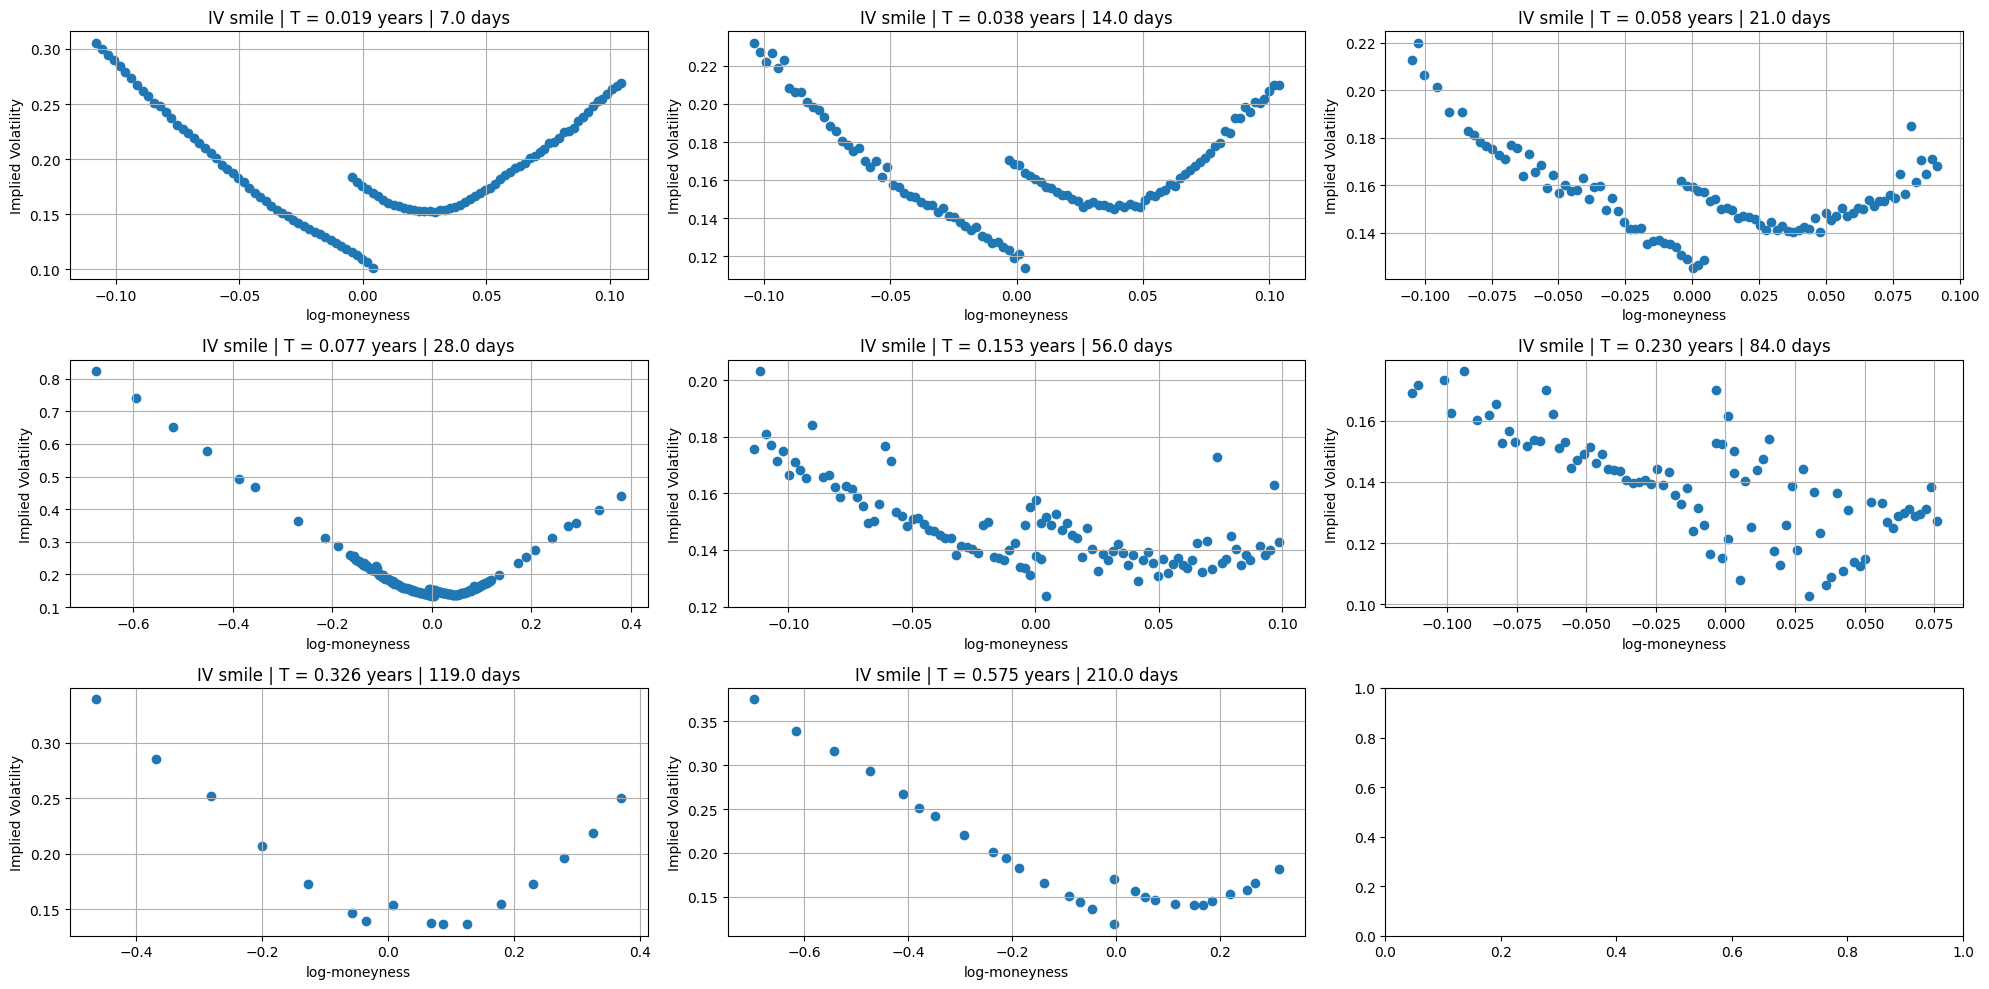

In [19]:
iv.plot_iv_smile(df)

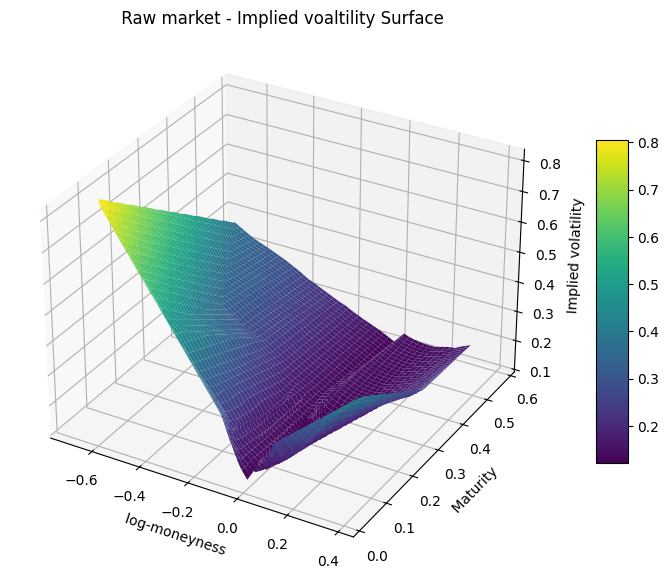

In [21]:
iv.plot_raw_iv(df)

In [25]:
stats = iv.surface_statistics(df)

RAW IMPLIED VOLATILITY SURFACE SUMMARY
Total Options            : 691
Unique Maturities        : 8
Unique Strikes           : 150
Mean IV                  : 0.171425
Median IV                : 0.153932
Std IV                   : 0.061459
Min IV                   : 0.101455
Max IV                   : 0.823323
Min Strike               : 12000
Max Strike               : 34500
Min k                    : -0.697284
Max k                    : 0.381207
Shortest Maturity        : 0.019178
Longest Maturity         : 0.575342
Missing IV               : 0
Duplicate (T,K)          : 0

ATM IMPLIED VOLATILITY
----------------------------------------------------------------------
 Maturity  Strike   ATM_IV
 0.019178   23500 0.175240
 0.038356   23500 0.168470
 0.057534   23550 0.159111
 0.076712   23550 0.152991
 0.153425   23650 0.137837
 0.230137   23750 0.161386
 0.326027   24000 0.153854
 0.575342   24000 0.170376

MATURITY SUMMARY
-----------------------------------------------------------------